In [47]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from typing import Annotated

In [ ]:
llm = ChatGroq(model="openai/gpt-oss-120b", max_tokens=1000)

In [59]:
def merge_evaluations(
    current: dict,
    new: dict
) -> dict:
    return {**current, **new}


class LLMScoreModel(BaseModel):
    score: float = Field(description="The score of the blog")
    issues: list[str] = Field(description="The issues found in the blog")

class BlogQualityEvaluator(BaseModel):
    blog: str = Field(description="The blog to evaluate")
    evaluations: Annotated[dict[str,LLMScoreModel], merge_evaluations] = Field(description="Aspect breakdown of the blog quality", default=BlogAspects())
    summary: str = Field(description="Summary of the blog quality", default="")

In [70]:
def evaluate_blog_accuracy(state: BlogQualityEvaluator) -> BlogQualityEvaluator:
    print("\n[Accuracy] Started")
    print(f"[Accuracy] Blog length: {len(state.blog)}")

    prompt = f'''
    Evaluate the blog for factual accuracy. Identify incorrect, misleading, or unsupported claims. 
    Give:
    - score from 1–10
    - maximum 5 important issues
    - Keep each issue under 20 words.

    Blog:
    {state.blog}
    '''

    accuracy_llm = llm.with_structured_output(LLMScoreModel)
    result = accuracy_llm.invoke(prompt)

    print(f"[Accuracy] Result: {result}")
    print("[Accuracy] Finished")

    return {"evaluations": {"accuracy": result}}


def evaluate_blog_structure(state: BlogQualityEvaluator) -> BlogQualityEvaluator:
    print("\n[Structure] Started")
    print(f"[Structure] Blog length: {len(state.blog)}")

    prompt = f'''
    Evaluate the blog's structure and logical flow. Check the introduction, organization, transitions, and conclusion. 
    Give:
    - score from 1–10
    - maximum 5 important issues
    - Keep each issue under 20 words.

    Blog:
    {state.blog}
    '''

    structure_llm = llm.with_structured_output(LLMScoreModel)
    result = structure_llm.invoke(prompt)

    print(f"[Structure] Result: {result}")
    print("[Structure] Finished")

    return {"evaluations": {"structure": result}}


def evaluate_blog_readability(state: BlogQualityEvaluator) -> BlogQualityEvaluator:
    print("\n[Readability] Started")
    print(f"[Readability] Blog length: {len(state.blog)}")

    prompt = f''' 
    Evaluate the blog for clarity and readability. Check language, sentence complexity, jargon, and overall ease of understanding.
    Give:
    - score from 1–10
    - maximum 5 important issues
    - Keep each issue under 20 words.

    Blog:
    {state.blog}
    '''

    readability_llm = llm.with_structured_output(LLMScoreModel)
    result = readability_llm.invoke(prompt)

    print(f"[Readability] Result: {result}")
    print("[Readability] Finished")

    return {"evaluations": {"readability": result}}


def aggregator(state: BlogQualityEvaluator) -> BlogQualityEvaluator:
    print("\n[Aggregator] Started")
    print(f"[Aggregator] Evaluations: {state.evaluations}")

    prompt = f''' 
    Combine the evaluation results. Calculate the overall score, summarize the main strengths and weaknesses, and provide the most important improvements.
    Evaluations: {state.evaluations}
    '''

    result = llm.invoke(prompt)

    print(f"[Aggregator] Result: {result}")
    print("[Aggregator] Finished")

    return {"summary": result.content}


def final_evaluation(state: BlogQualityEvaluator) -> BlogQualityEvaluator:
    print("\n[Final] Final evaluation:")
    print(f"[Final] {state}")

    return state

In [71]:
graph = StateGraph(BlogQualityEvaluator)

graph.add_node("evaluate_blog_accuracy",evaluate_blog_accuracy)
graph.add_node("evaluate_blog_structure",evaluate_blog_structure)
graph.add_node("evaluate_blog_readability",evaluate_blog_readability)
graph.add_node('aggregator', aggregator)

graph.add_edge(START, "evaluate_blog_accuracy")
graph.add_edge(START, "evaluate_blog_structure")
graph.add_edge(START, "evaluate_blog_readability")

graph.add_edge("evaluate_blog_accuracy", "aggregator")
graph.add_edge("evaluate_blog_structure", 'aggregator')
graph.add_edge("evaluate_blog_readability", 'aggregator')

graph.add_edge("aggregator", END)

workflow = graph.compile()

In [72]:
from pathlib import Path

file_path = Path('blog.txt')
content = file_path.read_text()

initial_state = {
    "blog": content
}

result = workflow.invoke(initial_state)

print(result)


[Accuracy] Started
[Accuracy] Blog length: 3736

[Readability] Started
[Readability] Blog length: 3736

[Structure] Started
[Structure] Blog length: 3736
[Readability] Result: score=7.0 issues=['Dense tables and bullet points hinder flow', 'Heavy jargon (e.g., AIaaS, prompt engineers) without lay explanations', 'Long sentences reduce readability', 'Inconsistent formatting disrupts visual scanning', 'Statistical claims lack source citations']
[Readability] Finished
[Structure] Result: score=6.0 issues=['Blog ends abruptly; conclusion missing.', 'Roadmap promises seven pillars, only first pillar presented.', 'Transitions between sections are weak; sudden jumps.', 'Formatting inconsistent after cutoff; bullet tables misaligned.', 'Statistical claims lack source citations.']
[Structure] Finished
[Accuracy] Result: score=5.0 issues=['30% AI‑generated articles claim lacks verifiable source and is likely exaggerated.', '$15\u202ftrillion GDP boost misstates PwC’s broader AI impact forecast.'

In [75]:
from IPython.display import Markdown,display

display(Markdown(result['summary']))

**Combined Evaluation**

| Dimension | Score | Weight (equal) |
|-----------|-------|----------------|
| Accuracy  | **5.0** | 1 |
| Readability| **7.0** | 1 |
| Structure | **6.0** | 1 |
| **Overall (average)** | **6.0 / 10** |

---

### Main Strengths  

| Dimension | What Worked Well |
|-----------|------------------|
| **Readability** | The piece contains a good amount of data and concrete numbers, which can be compelling for a tech‑savvy audience. |
| **Readability** | When the text is not bogged down by tables, the language is clear enough to convey the key ideas. |
| **Structure (partial)** | The introduction sets up a “seven‑pillar” roadmap, giving the reader an expectation of a systematic analysis. |
| **Accuracy (some)** | The overall theme – that AI is reshaping logistics – is correct and aligns with industry consensus. |

---

### Main Weaknesses  

| Dimension | Issues |
|-----------|--------|
| **Accuracy** | • 30 % of AI‑generated articles are presented as “claims” without any verifiable source; the figure is likely exaggerated.<br>• $15 trillion GDP boost misquotes PwC’s broader AI impact forecast.<br>• 70 % chatbot resolution rate is overstated and not universally documented.<br>• 15 % fuel‑cut claim for DHL lacks public evidence.<br>• AI‑generated‑content share conflates creation with publication, misleading the reader. |
| **Readability** | • Dense tables and bullet‑point blocks break the narrative flow.<br>• Heavy jargon (e.g., “AIaaS”, “prompt engineers”) is used without lay explanations.<br>• Long, complex sentences reduce scan‑ability.<br>• Inconsistent formatting (mis‑aligned bullet tables, abrupt line breaks). |
| **Structure** | • The article ends abruptly; no concluding section to tie the arguments together.<br>• The promised “seven pillars” roadmap only delivers the first pillar.<br>• Weak transitions cause sudden jumps between topics.<br>• Formatting inconsistencies after the cutoff (mis‑aligned tables, broken lists). |
| **Cross‑cutting** | • All three dimensions repeatedly flag missing source citations for statistical claims. |

---

### Most Important Improvements  

1. **Fact‑Check & Cite Sources**  
   * Verify every statistic (30 % AI‑generated articles, $15 trillion GDP boost, 70 % chatbot resolution, 15 % fuel reduction).<br>
   * Add inline citations or footnotes linking to the original reports (PwC, DHL, industry studies).  

2. **Complete the Roadmap & Add a Conclusion**  
   * Deliver the remaining six pillars or clearly state why they are omitted.<br>
   * End with a concise conclusion that recaps key take‑aways and suggests next steps for logistics firms.  

3. **Improve Transitions & Narrative Flow**  
   * Insert bridging sentences that explain why the discussion moves from one pillar to the next.<br>
   * Use sub‑headings that reflect the logical progression (e.g., “From Data Capture to Predictive Analytics”).  

4. **Simplify Language & Explain Jargon**  
   * Replace or define terms like “AIaaS”, “prompt engineers”, “LLM‑driven orchestration”.<br>
   * Break long sentences into 1‑2 short sentences; keep each sentence under 20 words where possible.  

5. **Clean Up Formatting**  
   * Convert dense tables into inline bullet points or simple charts that fit the blog layout.<br>
   * Ensure consistent bullet style, indentation, and spacing throughout the piece.  

6. **Add Visual Anchors**  
   * Use a summary table at the top that lists the seven pillars (even if only the first is expanded).<br>
   * Include a final “Key Metrics” box that reiterates verified numbers with their sources.  

---

**Bottom Line

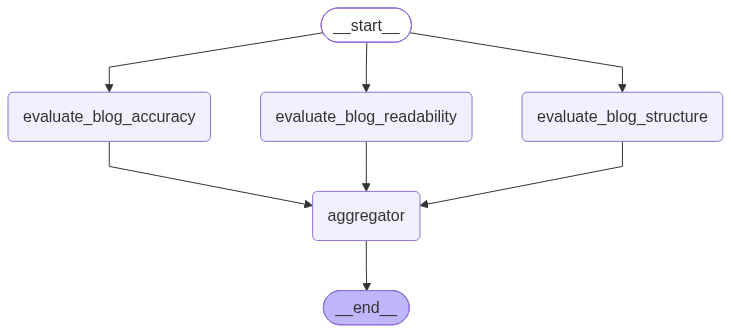

In [ ]:
from IPython.display import Image,display
display(Image(workflow.get_graph().draw_mermaid_png()))